In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_percentage_error, r2_score

In [3]:
df = pd.read_csv('perrin-freres-monthly-champagne.csv', skipfooter = 2, index_col ='Month', parse_dates = True, engine = 'python')

In [4]:
df.columns = ['Sales']

<Axes: xlabel='Month'>

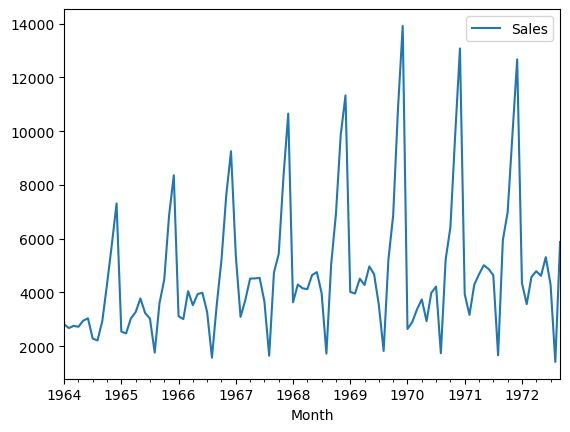

In [5]:
df.plot()

In [6]:
df['LogSales'] = np.log(df['Sales'])

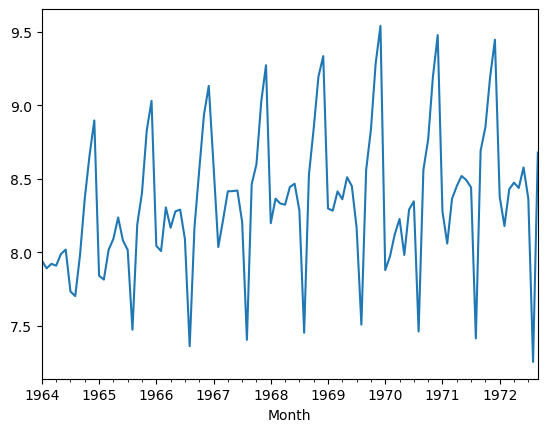

In [7]:
df['LogSales'].plot();

In [8]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [9]:
from statsmodels.tsa.stattools import adfuller

In [10]:
adfuller(df['LogSales'])

(np.float64(-2.2551186012844378),
 np.float64(0.18685173111686953),
 13,
 91,
 {'1%': np.float64(-3.50434289821397),
  '5%': np.float64(-2.8938659630479413),
  '10%': np.float64(-2.5840147047458037)},
 np.float64(-49.1914375158301))

In [11]:
''' looking at the plot and also at the raw plots, the data is non stationary -  we are not doing the differencing,
but we should try modeling the time series with differenced data''' 

' looking at the plot and also at the raw plots, the data is non stationary -  we are not doing the differencing,\nbut we should try modeling the time series with differenced data'

In [12]:
#make supervised dataset

series  = df['LogSales'].to_numpy()

T = 12
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T]
    y = series[t+T]
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1,T) # converting to numpy array since scikit learn expects the data to be in numppy array
Y = np.array(Y)
print("X.shape", X.shape, "Y.shape", Y.shape)


X.shape (93, 12) Y.shape (93,)


In [13]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

In [15]:
''' the above method is wrong since data leakage is happenning in test set which might give us misleading evaluation results.
ex - the first label in test set is the last feature in the next row of the test set'''

' the above method is wrong since data leakage is happenning in test set which might give us misleading evaluation results.\nex - the first label in test set is the last feature in the next row of the test set'

In [16]:
lr = LinearRegression()
lr.fit(Xtrain, Ytrain)
lr.score(Xtrain, Ytrain)

0.8682372095558998

In [17]:
lr.score(Xtest, Ytest)

0.9657520752272795

In [18]:
train_idx = df.index <= train.index[-1]
test_idx = ~train_idx

train_idx[:T] = False 
# since the 1st T values in train set are not predictable 
# when we created dataset in the loop above, 1st row of training data would be from raw_data[0:T] as features and raw_data[T] as label,
# hence no label for 1st T values

In [19]:
df.loc[train_idx, 'LR_1step_train'] = lr.predict(Xtrain)
df.loc[test_idx, 'LR_1step_test'] = lr.predict(Xtest)

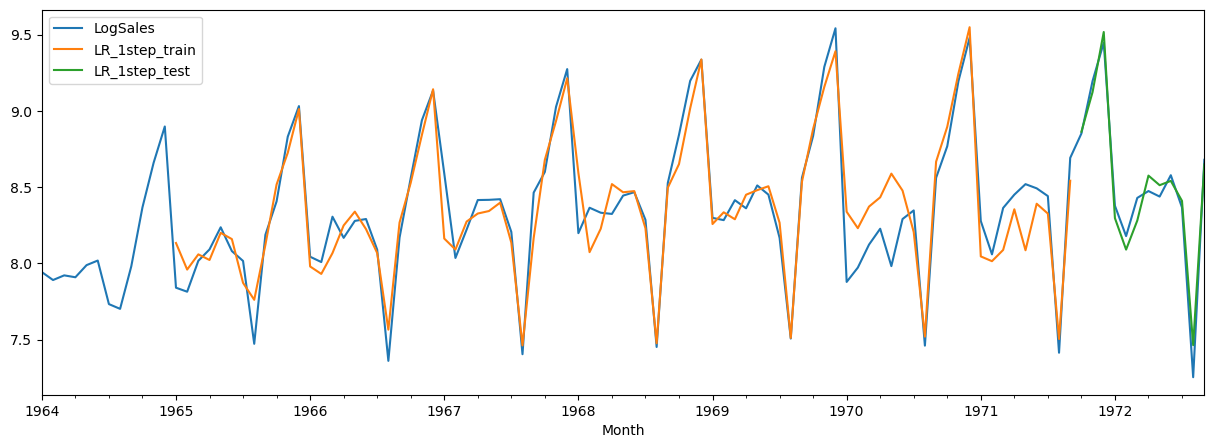

In [20]:
df[['LogSales','LR_1step_train','LR_1step_test']].plot(figsize = (15,5));

In [21]:
''' the above looks pretty good but its 1 step forecast which means for every time step, it is using the previous value
additionaly, data leakage could also be happenning in test set as label in the 1st row of test set is appearing as feature in the 2nd row'''

' the above looks pretty good but its 1 step forecast which means for every time step, it is using the previous value\nadditionaly, data leakage could also be happenning in test set as label in the 1st row of test set is appearing as feature in the 2nd row'

In [22]:
# multi-step forecast

multistep_predictions = []

last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
    p = lr.predict(last_x.reshape(1,-1))[0]

    multistep_predictions.append(p)

    last_x = np.roll(last_x, -1)
    last_x[-1] = p

In [23]:
df.loc[test_idx, 'LR_multistep'] = multistep_predictions

In [24]:
'''this is the correct method and no data leakage is happenning here in test set. this is how ARIMA does it'''

'this is the correct method and no data leakage is happenning here in test set. this is how ARIMA does it'

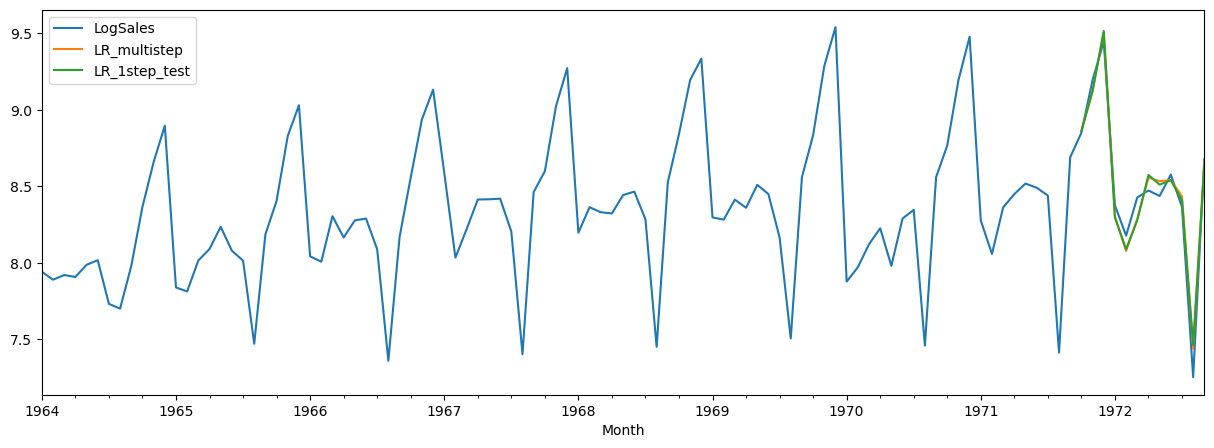

In [25]:
df[['LogSales','LR_multistep','LR_1step_test']].plot(figsize = (15,5));

In [26]:
# multioutput dataset prep
Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) -Tx - Ty + 1):
    x = series[t:t+Tx]
    y = series[t+Tx:t+Tx+Ty]
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1,Tx)
Y = np.array(Y).reshape(-1,Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (82, 12) Y.shape (82, 12)


In [27]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [28]:
lr = LinearRegression()
lr.fit(Xtrain_m, Ytrain_m)
lr.score(Xtrain_m, Ytrain_m)

0.8829262390390559

In [31]:
''' the r2 score above is not comparable to other models since the above is outputing multioutput not single output'''
'''but overall score appears to be very good when we look at the scores in isolation'''

'but overall score appears to be very good when we look at the scores in isolation'

In [32]:
r2_score (lr.predict(Xtest_m).flatten(), Ytest_m.flatten())

0.9595107879158431

In [33]:
''' score appears to be very good - slightly less than the multistep though'''

' score appears to be very good - slightly less than the multistep though'

In [35]:
df.loc[test_idx,'LR_multioutput'] = lr.predict(Xtest_m).flatten()

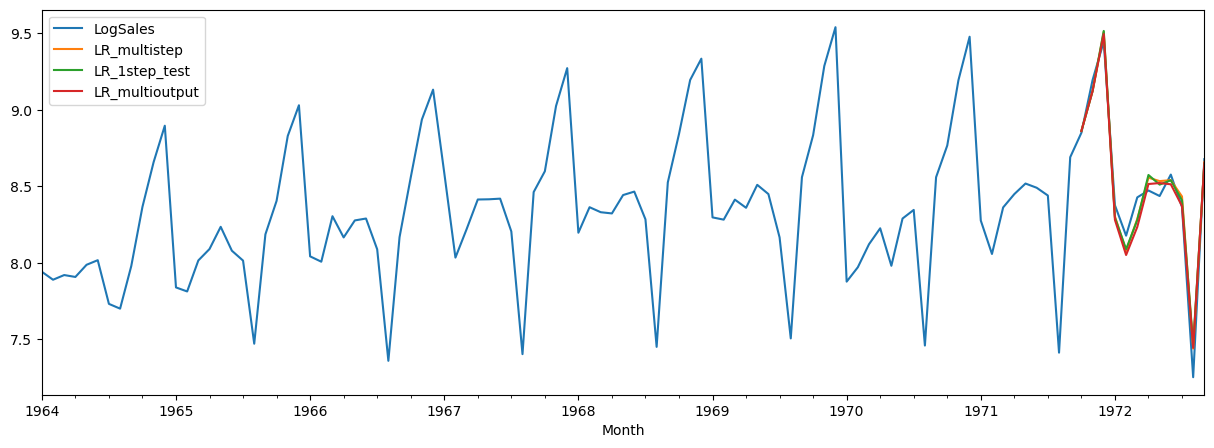

In [36]:
cols = ['LogSales','LR_multistep','LR_1step_test','LR_multioutput']
df[cols].plot(figsize = (15,5));

In [37]:
mape1 = mean_absolute_percentage_error(Ytest, multistep_predictions)
print("multi-step MAPE: ", mape1)

mape2 = mean_absolute_percentage_error(Ytest, df.loc[test_idx,'LR_multioutput'])
print("multi-output MAPE: ", mape2)

multi-step MAPE:  0.00960716937379765
multi-output MAPE:  0.009727020853255825


# test other models

In [38]:
def one_step_and_multistep_forecast(model, name):
    model.fit(Xtrain, Ytrain)
    print("One Step forecast", name)

    df.loc[train_idx, f'{name}_1step_train'] = model.predict(Xtrain)
    df.loc[test_idx, f'{name}_1step_test'] = model.predict(Xtest)

    multistep_predictions = []
    last_x = Xtest[0]
    
    while len(multistep_predictions) < Ntest:
        p = model.predict(last_x.reshape(1,-1))[0]

        multistep_predictions.append(p)

        last_x = np.roll(last_x,-1)
        last_x[-1] = p

    df.loc[test_idx, f'{name}_multistep_test'] = multistep_predictions
    mape = mean_absolute_percentage_error(Ytest, multistep_predictions)
    print("Test MAPE(multi-step):", mape)

    cols = [
        'LogSales',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test'
    ]

    df[cols].plot(figsize=(15,5));
        
    

One Step forecast SVR
Test MAPE(multi-step): 0.013188370472848111


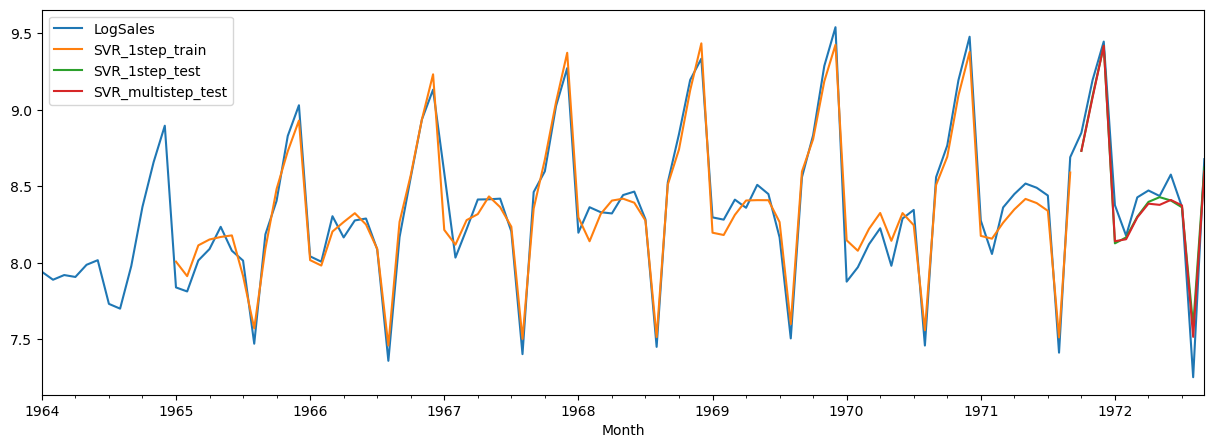

In [39]:
one_step_and_multistep_forecast(SVR(), 'SVR')

One Step forecast RF
Test MAPE(multi-step): 0.011329989378585035


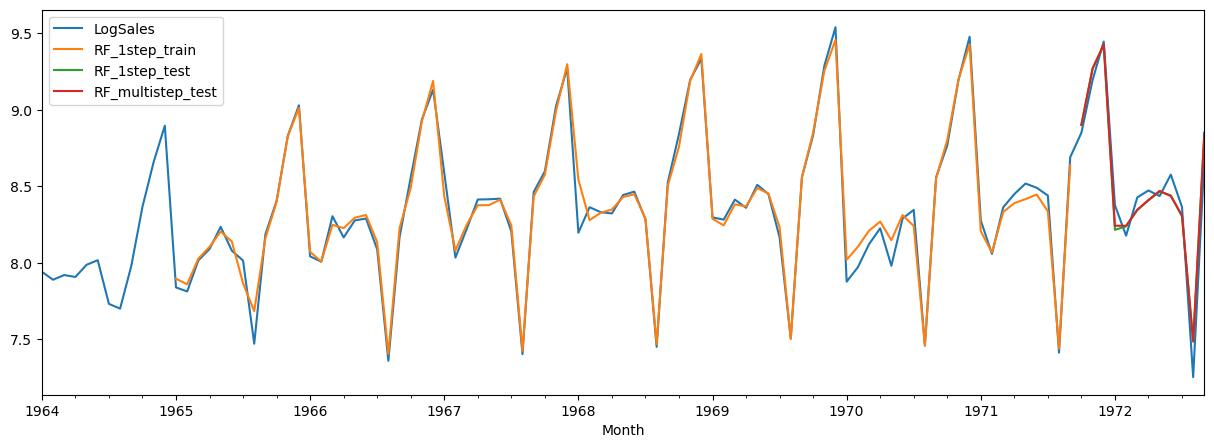

In [40]:
one_step_and_multistep_forecast(RandomForestRegressor(), 'RF')

In [41]:
def multi_output_forecast(model, name):
    
    model.fit(Xtrain_m, Ytrain_m)
    
    # 1 step forecast
    
    df.loc[test_idx, f'{name}_multioutput'] = model.predict(Xtest_m).flatten()

    mape = mean_absolute_percentage_error(Ytest, df.loc[test_idx, f'{name}_multioutput'])
    print("Test MAPE (multi-output):", mape)
    
    #
    cols = [
        'LogSales',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test',
        f'{name}_multioutput'
    ]
    
    df[cols].plot(figsize =(15,5));    

Test MAPE (multi-output): 0.019593307623188057


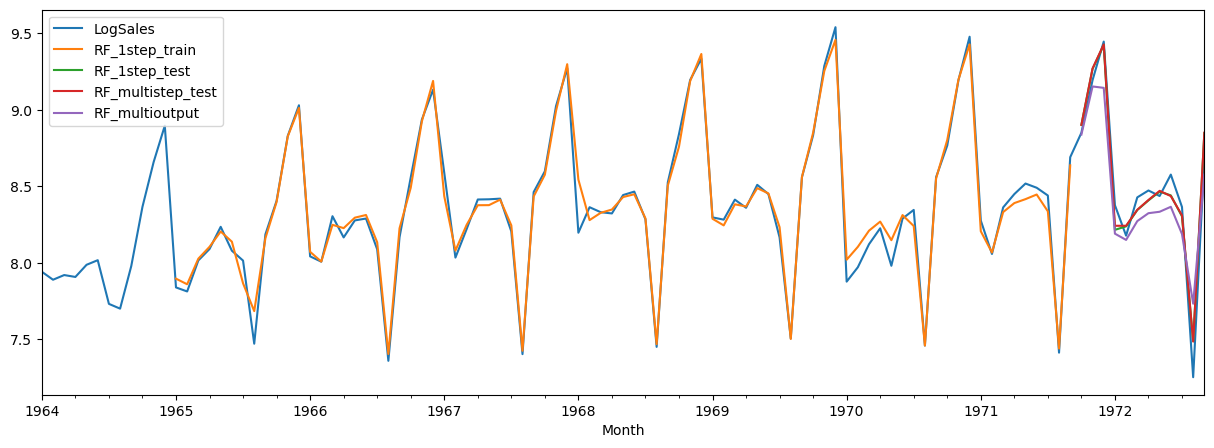

In [42]:
multi_output_forecast(RandomForestRegressor(), 'RF')

In [43]:
# doing the same with differencing and see if it helps